Name: Priscilla Otu

# Amazon Alexa Review Sentiment Analysis

## Assignment Objective
This project applies Natural Language Processing (NLP) and machine learning techniques to classify Amazon Alexa customer reviews as **positive (1)** or **negative (0)**.

The notebook follows the assignment tasks:
1. Dataset Selection and Preprocessing
2. Feature Engineering
3. Traditional Text Classification
4. Sentiment Analysis Using BERT
5. Model Evaluation
6. Deployment Strategy and Conclusion

**Dataset:** Amazon Alexa Reviews (`amazon_alexa.tsv`), a publicly available sentiment-analysis dataset containing customer reviews and feedback labels.


## Task 1: Dataset Selection and Preprocessing

### Task 1.1: Install and Import Required Libraries

In [3]:

!pip -q install transformers datasets accelerate gensim

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

print("Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.3 MB/s eta 0:00:00
Libraries imported successfully.


### Task 1.2: Load the Public Amazon Alexa Reviews Dataset

In [4]:
# Public copy of the Amazon Alexa Reviews dataset
url = "https://raw.githubusercontent.com/sharmaroshan/Amazon-Alexa-Reviews/master/amazon_alexa.tsv"

df = pd.read_csv(url, sep="\t")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


### Task 1.3: Examine the Dataset

In [5]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nFeedback distribution:")
print(df["feedback"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB
None

Missing values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

Feedback distribution:
feedback
1    2893
0     257
Name: count, dtype: int64


### Task 1.4: Handle Missing Values and Duplicates

In [6]:
# Keep the columns needed for sentiment analysis
data = df[["verified_reviews", "feedback"]].copy()

# Remove missing reviews and duplicate rows
data = data.dropna(subset=["verified_reviews"])
data = data.drop_duplicates()

print("Cleaned dataset shape:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())

Cleaned dataset shape: (2301, 2)
Remaining missing values: 0


### Task 1.5: Clean and Transform the Review Text

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_review"] = data["verified_reviews"].apply(clean_text)

data[["verified_reviews", "clean_review", "feedback"]].head()

,verified_reviews,clean_review,feedback
0,Love my Echo!,love my echo,1
1,Loved it!,loved it,1
2,"Sometimes while playing a game, you can answer...",sometimes while playing a game you can answer ...,1
3,I have had a lot of fun with this thing. My 4 ...,i have had a lot of fun with this thing my yr ...,1
4,Music,music,1


### Preprocessing Note
Feature scaling is not required for raw text. One-hot encoding is also not required because the target variable (`feedback`) is already numeric: **1 = positive** and **0 = negative**.


### Task 1.6: Visualize Sentiment Distribution

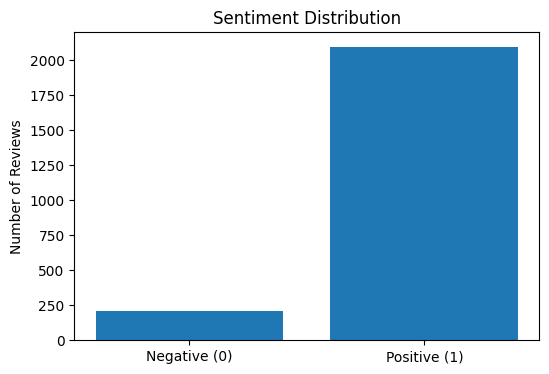

,count
feedback,
0,206
1,2095


In [8]:
sentiment_counts = data["feedback"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Negative (0)", "Positive (1)"], sentiment_counts.values)
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution")
plt.show()

sentiment_counts

### Task 1.7: Split the Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_review"],
    data["feedback"],
    test_size=0.20,
    random_state=42,
    stratify=data["feedback"]
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 1840
Testing reviews: 461


## Task 2: Feature Engineering

### Task 2.1: Bag of Words

In [10]:
bow = CountVectorizer(max_features=3000, stop_words="english")

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("Bag of Words training shape:", X_train_bow.shape)
print("Sample features:", bow.get_feature_names_out()[:20])

Bag of Words training shape: (1840, 3000)
Sample features: ['abilities' 'ability' 'able' 'absolutely' 'ac' 'accent' 'access'
 'accessible' 'accessing' 'accessories' 'accesss' 'accident'
 'accidentally' 'accompanying' 'accomplish' 'accomplished' 'according'
 'accordingly' 'account' 'accounts']


### Task 2.2: TF-IDF Vectorization

In [11]:
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)

TF-IDF training shape: (1840, 3000)


### Task 2.3: Word Embeddings Using Word2Vec

In [12]:
tokenized_reviews = [review.split() for review in data["clean_review"] if review.strip()]

w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=50,
    window=5,
    min_count=2,
    workers=2,
    seed=42
)

print("Word2Vec vocabulary size:", len(w2v_model.wv))
print("Embedding size:", w2v_model.vector_size)

Word2Vec vocabulary size: 2156
Embedding size: 50


### Task 2.4: Visualize Word Embeddings Using PCA

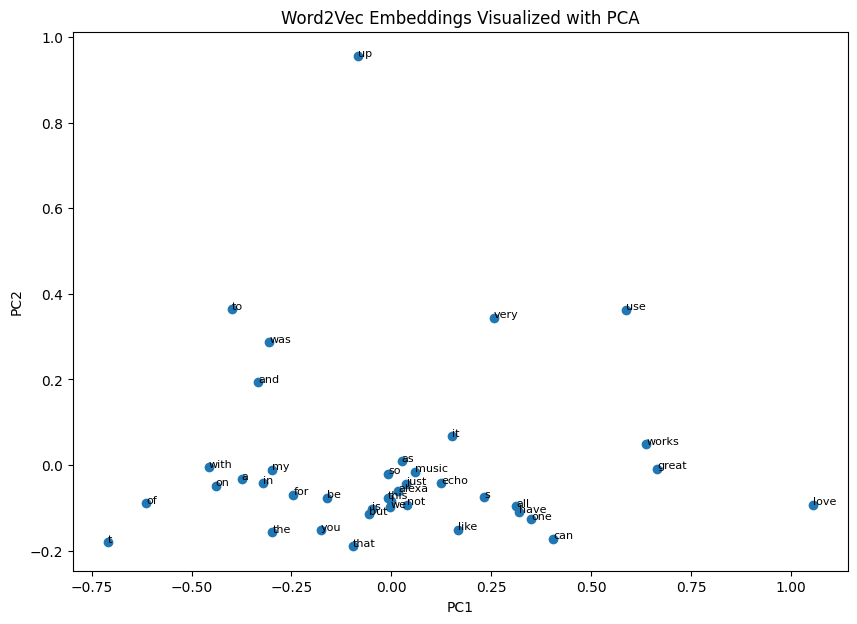

In [13]:
# Select common words from the Word2Vec vocabulary
words = w2v_model.wv.index_to_key[:40]
vectors = np.array([w2v_model.wv[word] for word in words])

pca_words = PCA(n_components=2)
coords = pca_words.fit_transform(vectors)

plt.figure(figsize=(10,7))
plt.scatter(coords[:,0], coords[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (coords[i,0], coords[i,1]), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Word2Vec Embeddings Visualized with PCA")
plt.show()

## Task 3: Text Classification Using Traditional Models

### Task 3.1: Logistic Regression with GridSearchCV

In [14]:
lr_grid = {
    "C": [0.1, 1, 10]
}

lr_search = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    lr_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

lr_search.fit(X_train_tfidf, y_train)

lr_model = lr_search.best_estimator_
lr_pred = lr_model.predict(X_test_tfidf)
lr_prob = lr_model.predict_proba(X_test_tfidf)[:,1]

print("Best Logistic Regression parameters:", lr_search.best_params_)

Best Logistic Regression parameters: {'C': 10}


### Task 3.2: Support Vector Machine with GridSearchCV

In [15]:
svm_grid = {
    "C": [0.1, 1, 10]
}

svm_search = GridSearchCV(
    LinearSVC(class_weight="balanced"),
    svm_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

svm_search.fit(X_train_tfidf, y_train)

best_svm = svm_search.best_estimator_

# Calibration provides probabilities required for ROC-AUC and ROC curve
svm_model = CalibratedClassifierCV(best_svm, cv=3)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_prob = svm_model.predict_proba(X_test_tfidf)[:,1]

print("Best SVM parameters:", svm_search.best_params_)

Best SVM parameters: {'C': 1}


## Task 4: Sentiment Analysis Using BERT

### Task 4.1: Prepare BERT

The code fine-tunes a pre-trained BERT model on the Alexa sentiment dataset. A smaller sample is used to keep the assignment practical in Colab.


In [16]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Use a manageable stratified sample for BERT fine-tuning
bert_data = data[["clean_review", "feedback"]].rename(
    columns={"clean_review": "text", "feedback": "label"}
)

# Keep all negatives and sample positives to reduce class imbalance and runtime
negative = bert_data[bert_data["label"] == 0]
positive = bert_data[bert_data["label"] == 1].sample(
    n=min(len(negative) * 2, len(bert_data[bert_data["label"] == 1])),
    random_state=42
)
bert_data = pd.concat([negative, positive]).sample(frac=1, random_state=42).reset_index(drop=True)

bert_train, bert_test = train_test_split(
    bert_data,
    test_size=0.20,
    random_state=42,
    stratify=bert_data["label"]
)

train_ds = Dataset.from_pandas(bert_train.reset_index(drop=True))
test_ds = Dataset.from_pandas(bert_test.reset_index(drop=True))

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("BERT training samples:", len(train_ds))
print("BERT testing samples:", len(test_ds))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/494 [00:00<?, ? examples/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]

BERT training samples: 494
BERT testing samples: 124


### Task 4.2: Fine-Tune BERT

In [17]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    report_to="none",
    save_strategy="no"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds
)

trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,0.621466
40,0.487166
60,0.383964


TrainOutput(global_step=62, training_loss=0.4924969173246814, metrics={'train_runtime': 11.5098, 'train_samples_per_second': 85.84, 'train_steps_per_second': 5.387, 'total_flos': 32719447468032.0, 'train_loss': 0.4924969173246814, 'epoch': 2.0})

### Task 4.3: Generate BERT Predictions

In [18]:
bert_output = trainer.predict(test_ds)

bert_logits = bert_output.predictions
bert_pred = np.argmax(bert_logits, axis=1)

exp_logits = np.exp(bert_logits - np.max(bert_logits, axis=1, keepdims=True))
bert_prob = exp_logits[:,1] / exp_logits.sum(axis=1)

bert_true = bert_test["label"].to_numpy()

print("BERT predictions generated:", len(bert_pred))

BERT predictions generated: 124


## Task 5: Model Evaluation

### Task 5.1: Calculate Accuracy, Precision, Recall, F1-Score and ROC-AUC

In [19]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob),
    evaluate_model("SVM", y_test, svm_pred, svm_prob),
    evaluate_model("BERT", bert_true, bert_pred, bert_prob)
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9024,0.9475,0.9452,0.9464,0.9003
1,SVM,0.9154,0.9262,0.9857,0.9550,0.8944
2,BERT,0.8548,0.8351,0.9759,0.9000,0.9450


### Task 5.2: Confusion Matrices

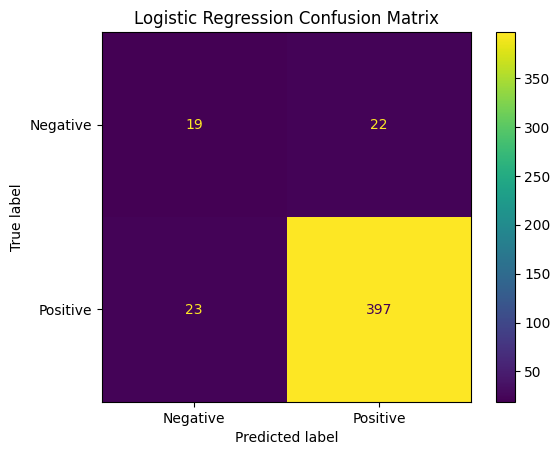

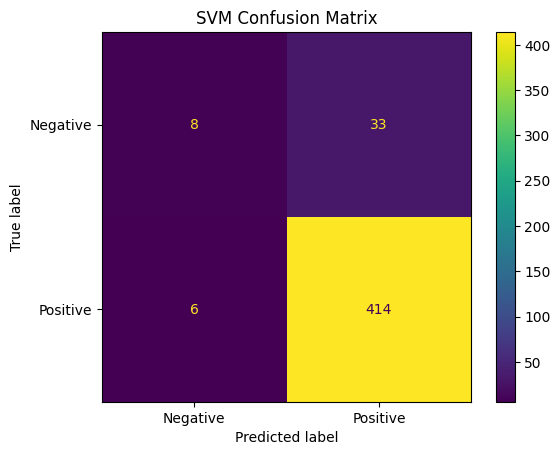

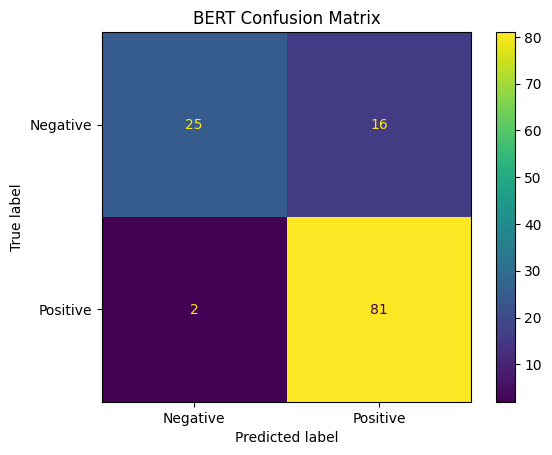

In [20]:
models_to_plot = [
    ("Logistic Regression", y_test, lr_pred),
    ("SVM", y_test, svm_pred),
    ("BERT", bert_true, bert_pred)
]

for name, true_values, predictions in models_to_plot:
    ConfusionMatrixDisplay.from_predictions(
        true_values,
        predictions,
        display_labels=["Negative", "Positive"]
    )
    plt.title(f"{name} Confusion Matrix")
    plt.show()

### Task 5.3: ROC Curves

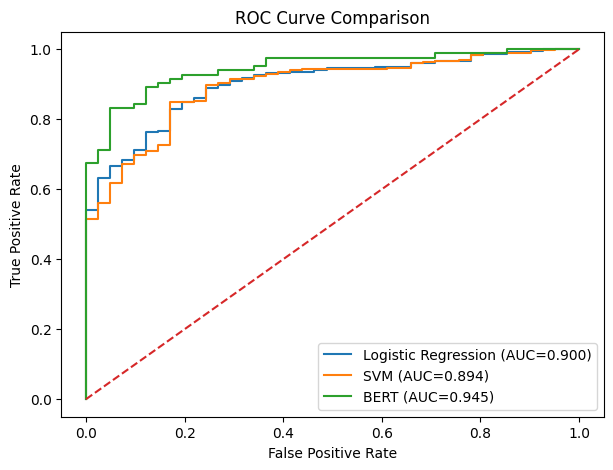

In [21]:
plt.figure(figsize=(7,5))

for name, true_values, probabilities in [
    ("Logistic Regression", y_test, lr_prob),
    ("SVM", y_test, svm_prob),
    ("BERT", bert_true, bert_prob)
]:
    fpr, tpr, _ = roc_curve(true_values, probabilities)
    auc = roc_auc_score(true_values, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### Task 5.4: Model Performance Chart

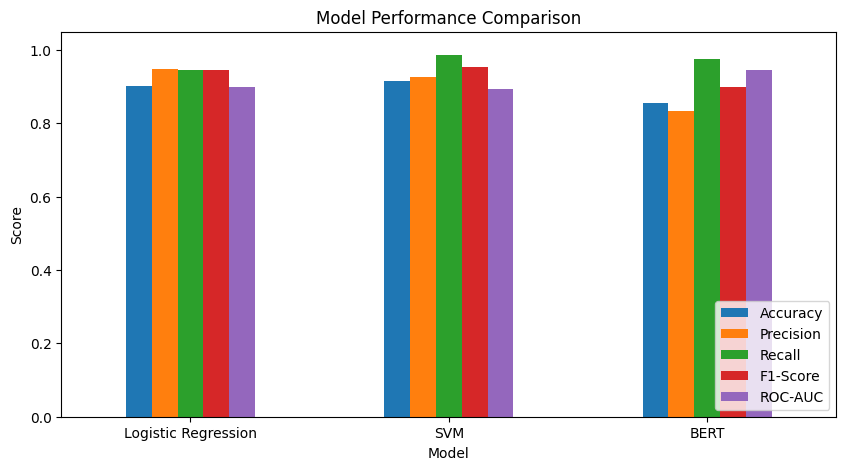

In [22]:
plot_results = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]

plot_results.plot(kind="bar", figsize=(10,5))
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

### Task 5.5: Feature Importance for Logistic Regression

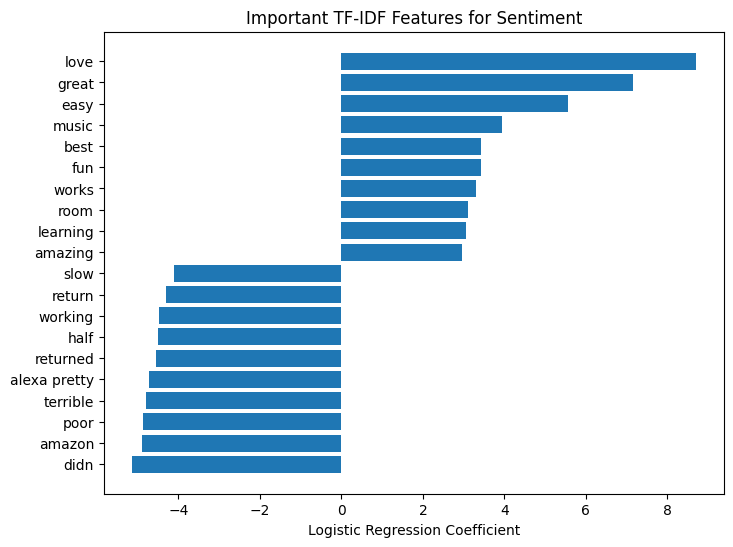

,Feature,Coefficient
0,didn,-5.139888
1,amazon,-4.884220
2,poor,-4.870262
3,terrible,-4.784850
4,alexa pretty,-4.721037
5,returned,-4.555465
6,half,-4.491870
7,working,-4.475228
8,return,-4.298814
9,slow,-4.099817


In [23]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = lr_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-10:]
top_negative_idx = np.argsort(coefficients)[:10]

importance_df = pd.DataFrame({
    "Feature": np.concatenate([
        feature_names[top_negative_idx],
        feature_names[top_positive_idx]
    ]),
    "Coefficient": np.concatenate([
        coefficients[top_negative_idx],
        coefficients[top_positive_idx]
    ])
}).sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.title("Important TF-IDF Features for Sentiment")
plt.show()

importance_df

### Task 5.6: Select the Best Model

In [24]:
best_row = results.loc[results["F1-Score"].idxmax()]

print("Best model based on F1-Score:", best_row["Model"])
print("Best F1-Score:", round(best_row["F1-Score"], 4))

Best model based on F1-Score: SVM
Best F1-Score: 0.955


## Task 6: Deployment Strategy and Conclusion

### Deployment Strategy
The best-performing sentiment model could be deployed as a REST API using Flask or FastAPI. A customer review would be submitted to the API, cleaned using the same preprocessing steps, transformed using the appropriate tokenizer/vectorizer, and classified as positive or negative.

### Potential Deployment Challenges
- **Latency:** BERT requires more computation than traditional models.
- **Scalability:** The service must handle multiple customer reviews efficiently.
- **Data drift:** Customer vocabulary and product terminology can change over time.
- **Maintenance:** Models, tokenizers, and preprocessing steps must be versioned together.
- **Class imbalance:** The Alexa dataset contains more positive than negative reviews.

### Monitoring and Updating
Model performance should be monitored using accuracy, precision, recall, F1-score and ROC-AUC when new labeled data becomes available. Input text distributions and sentiment proportions should also be monitored. The model should be retrained when performance declines or enough new review data has accumulated.

### Conclusion
This project compares Logistic Regression, Support Vector Machine and a fine-tuned BERT model for Amazon Alexa review sentiment classification. Bag of Words, TF-IDF and Word2Vec are used for numerical text representation, while PCA visualizes semantic relationships in the Word2Vec embeddings. The final model is selected using the required evaluation metrics.
